In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1-1 利用 matplotlib 顯示圖片

In [46]:
def show_img_in_jupyter(img):
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.show()

### 1-2-1 建立全黑的圖片

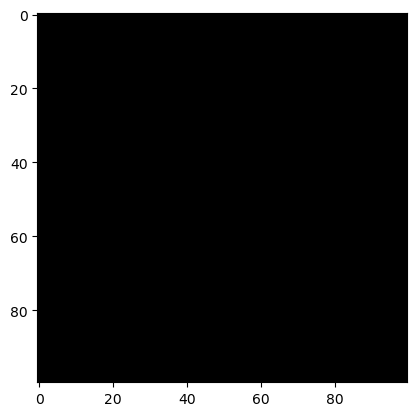

In [47]:
shape = (100, 100, 3) # 建立 100 * 100 的全黑圖片，三個參數對應 y, x, RGB
origin_img = np.zeros(shape, np.uint8) # 設定圖片每個像素值為 0
show_img_in_jupyter(origin_img) # 顯示圖片

### 1-2-2 建立全白的圖片

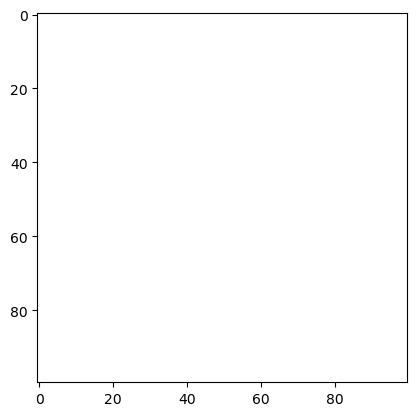

In [48]:
# 方法一：透過 np.full 直接建立一個所有像素值為 255 的圖片
shape = (100, 100, 3) # y, x, RGB
origin_img = np.full(shape, 255).astype(np.uint8) # 直接填滿白色
show_img_in_jupyter(origin_img) # 顯示圖片

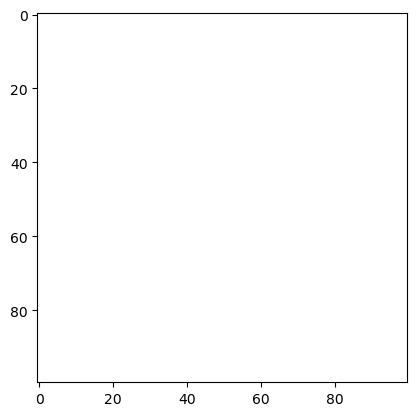

In [49]:
# 方法二：先建立一個全黑的圖片，再透過 img.fill(255) 將所有像素填上白色
shape = (100, 100, 3) # y, x, RGB
origin_img = np.zeros(shape, np.uint8) # 建立全黑圖片
origin_img.fill(255) # 填滿白色
show_img_in_jupyter(origin_img) # 顯示圖片

### 1-2-3 建立其他純色圖片

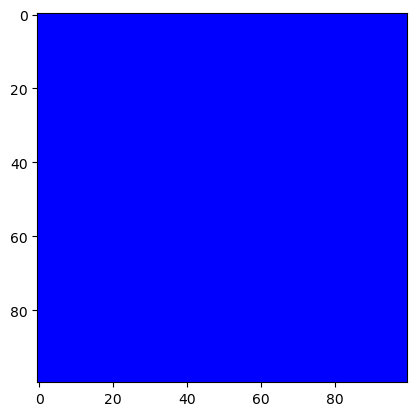

In [50]:
# 藍色圖片：將 B通道填滿 (B=255, G=0, R=0)

shape = (100, 100, 3)  
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 0] = 255  # 把B通道填滿, 兩個「:」分別替代 y,x 在該通道的所有座標點 
show_img_in_jupyter(origin_img) # 透過 matplotlib 顯示圖片

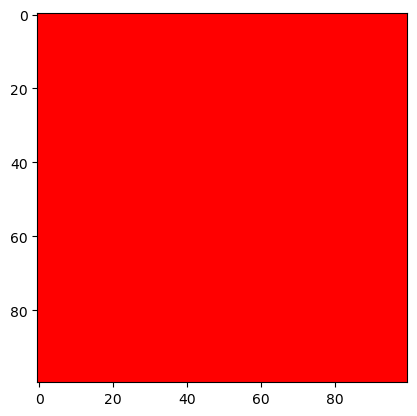

In [51]:
# 紅色圖片：將 R通道填滿 (B=0, G=0, R=255)

shape = (100, 100, 3)  
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 2] = 255  # 把 R通道填滿, 兩個「:」分別替代 y,x 在該通道的所有座標點 
show_img_in_jupyter(origin_img)

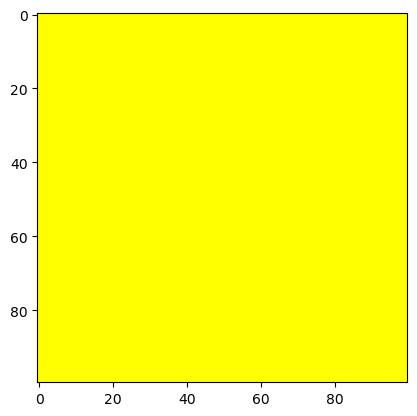

In [52]:
# 黃色圖片：綠色加紅色可以得到黃色，因此我們將 G, R通道填滿 (B=0, G=255, R=255)

shape = (100, 100, 3)  
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 1] = 255  # 把 G通道填滿
origin_img[:, :, 2] = 255  # 把 R通道填滿 
show_img_in_jupyter(origin_img)

## 1-3 利用 OpenCV 讀取圖片檔案

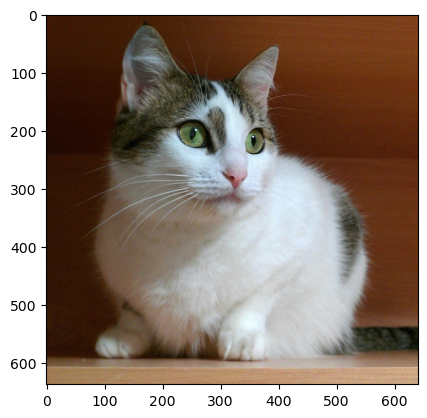

In [53]:
file_name = "sample/cat.jpg"  # 指定圖片的檔案名稱及路徑，範例中圖片位於 "sample" 資料夾內
origin_img = cv2.imread(file_name)  # 使用 OpenCV 的 imread 函式讀取圖片，並將結果存入 origin_img
show_img_in_jupyter(origin_img)  # 呼叫自定義函式，將讀取的圖片顯示在 JupyterLab 中

## 1-4 利用 OpenCV 讀取圖片檔案

In [54]:
file_name = "sample/cat.jpg" # 圖片路徑
origin_img = cv2.imread(file_name) # 讀取圖片
cv2.imshow('Image window', origin_img) # 顯示圖片

cv2.waitKey(0) # 暫停等待按鍵，使 cv2.imshow 能顯示出畫面
cv2.destroyAllWindows() # 搭配上一行，按下任意鍵則關閉所有視窗

### 補充：如果讀者想要做針對使用者可能誤按「X」的操作進行防呆，這裡也提供以下程式碼供讀者參考。 
(本書之後也會使用這段程式碼，避免讀者誤按、導致系統沒有回應的問題)

In [55]:
file_name = "sample/cat.jpg" # 圖片路徑
origin_img = cv2.imread(file_name) # 讀取圖片
cv2.imshow("Image window", origin_img)

while True:
    key = cv2.waitKey(1)  # 每 1ms 檢查一次
    # 檢查視窗是否被手動關閉（getWindowProperty 回傳值 < 0）
    if cv2.getWindowProperty("Image window", cv2.WND_PROP_VISIBLE) < 1:
        break
    if key == ord('q'):  # 按 Q 鍵也能關閉
        break
cv2.destroyAllWindows()

## 1-5 利用 OpenCV 儲存圖片

In [56]:
file_name = "sample/cat.jpg" # 圖片路徑
origin_img = cv2.imread(file_name) # 讀取圖片
cv2.imwrite("out.jpg", origin_img) # 儲存圖片

True

### 1-5-1 進階應用：圖片轉檔

In [57]:
file_name = "sample/cat.jpg" # 圖片路徑
origin_img = cv2.imread(file_name) # 讀取圖片
cv2.imwrite("cat.png", origin_img) # 儲存圖片

True

## 1-E 小專案 – 封裝本章的程式，方便日後使用

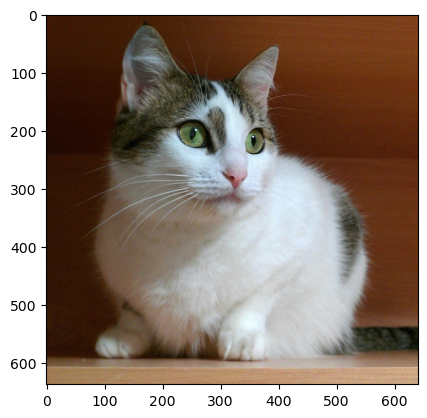

In [58]:
import cv2
from opencv_tools import opencv_tools # 匯入封裝的功能

file_name = "sample/cat.jpg" # 圖片路徑
img = cv2.imread(file_name) # 讀取圖片
opencv_tools.show_img_by_matplotlib(img) # 使用封裝好的 matplotlib 顯示圖片功能
opencv_tools.show_img_by_opencv(img) # 使用封裝好的 OpenCV 內建函式顯示圖片功能

### 1-E-4 進階：將 matplotlib 同時顯示多圖片的功能封裝

1.「show_img_by_matplotlib_2x1」：同時顯示兩張圖片，排列方式為一行兩列。

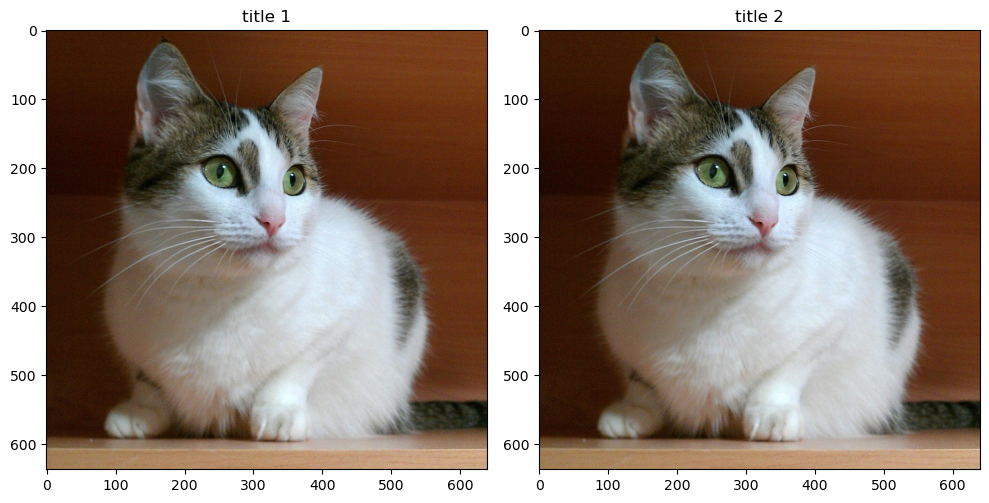

In [59]:
# 使用 matplitlib subplot 功能同時顯示 2 組結果
opencv_tools.show_img_by_matplotlib_2x1(
    "title 1", img, 
    "title 2", img
)

2.「show_img_by_matplotlib_3x1」：同時顯示三張圖片，排列方式為一行三列。

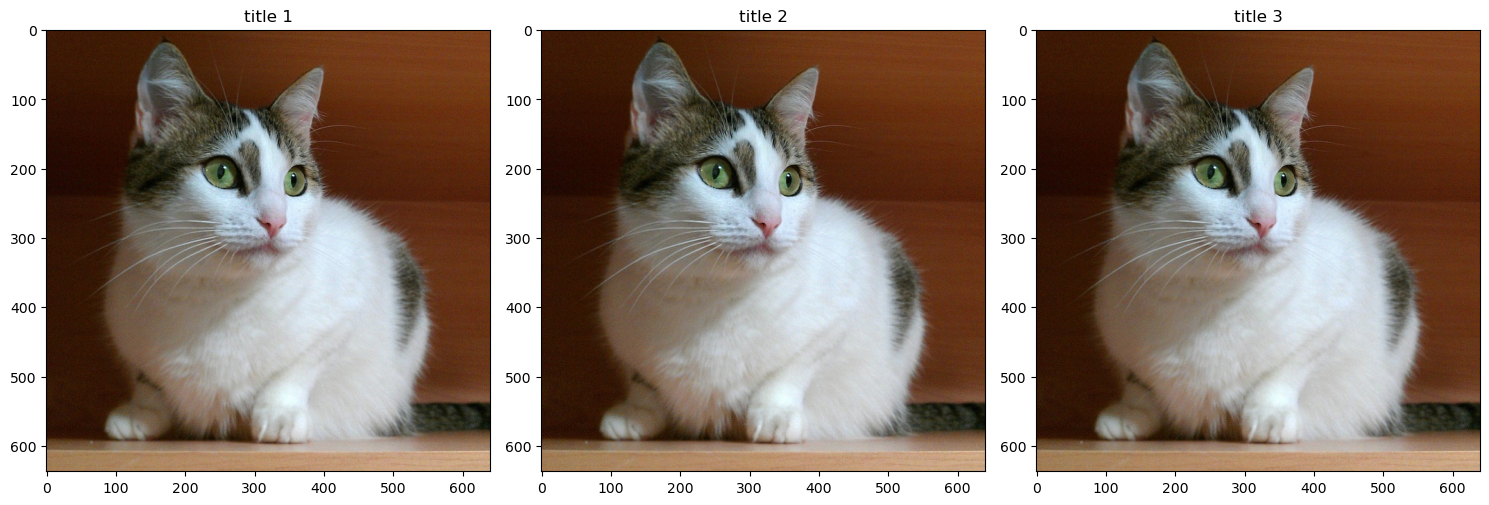

In [60]:
# 使用 matplitlib subplot 功能同時顯示 3 組結果
opencv_tools.show_img_by_matplotlib_3x1(
    "title 1", img,
    "title 2", img, 
    "title 3", img
)

3.「show_img_by_matplotlib_2x2」：同時顯示四張圖片，排列方式為二行二列。

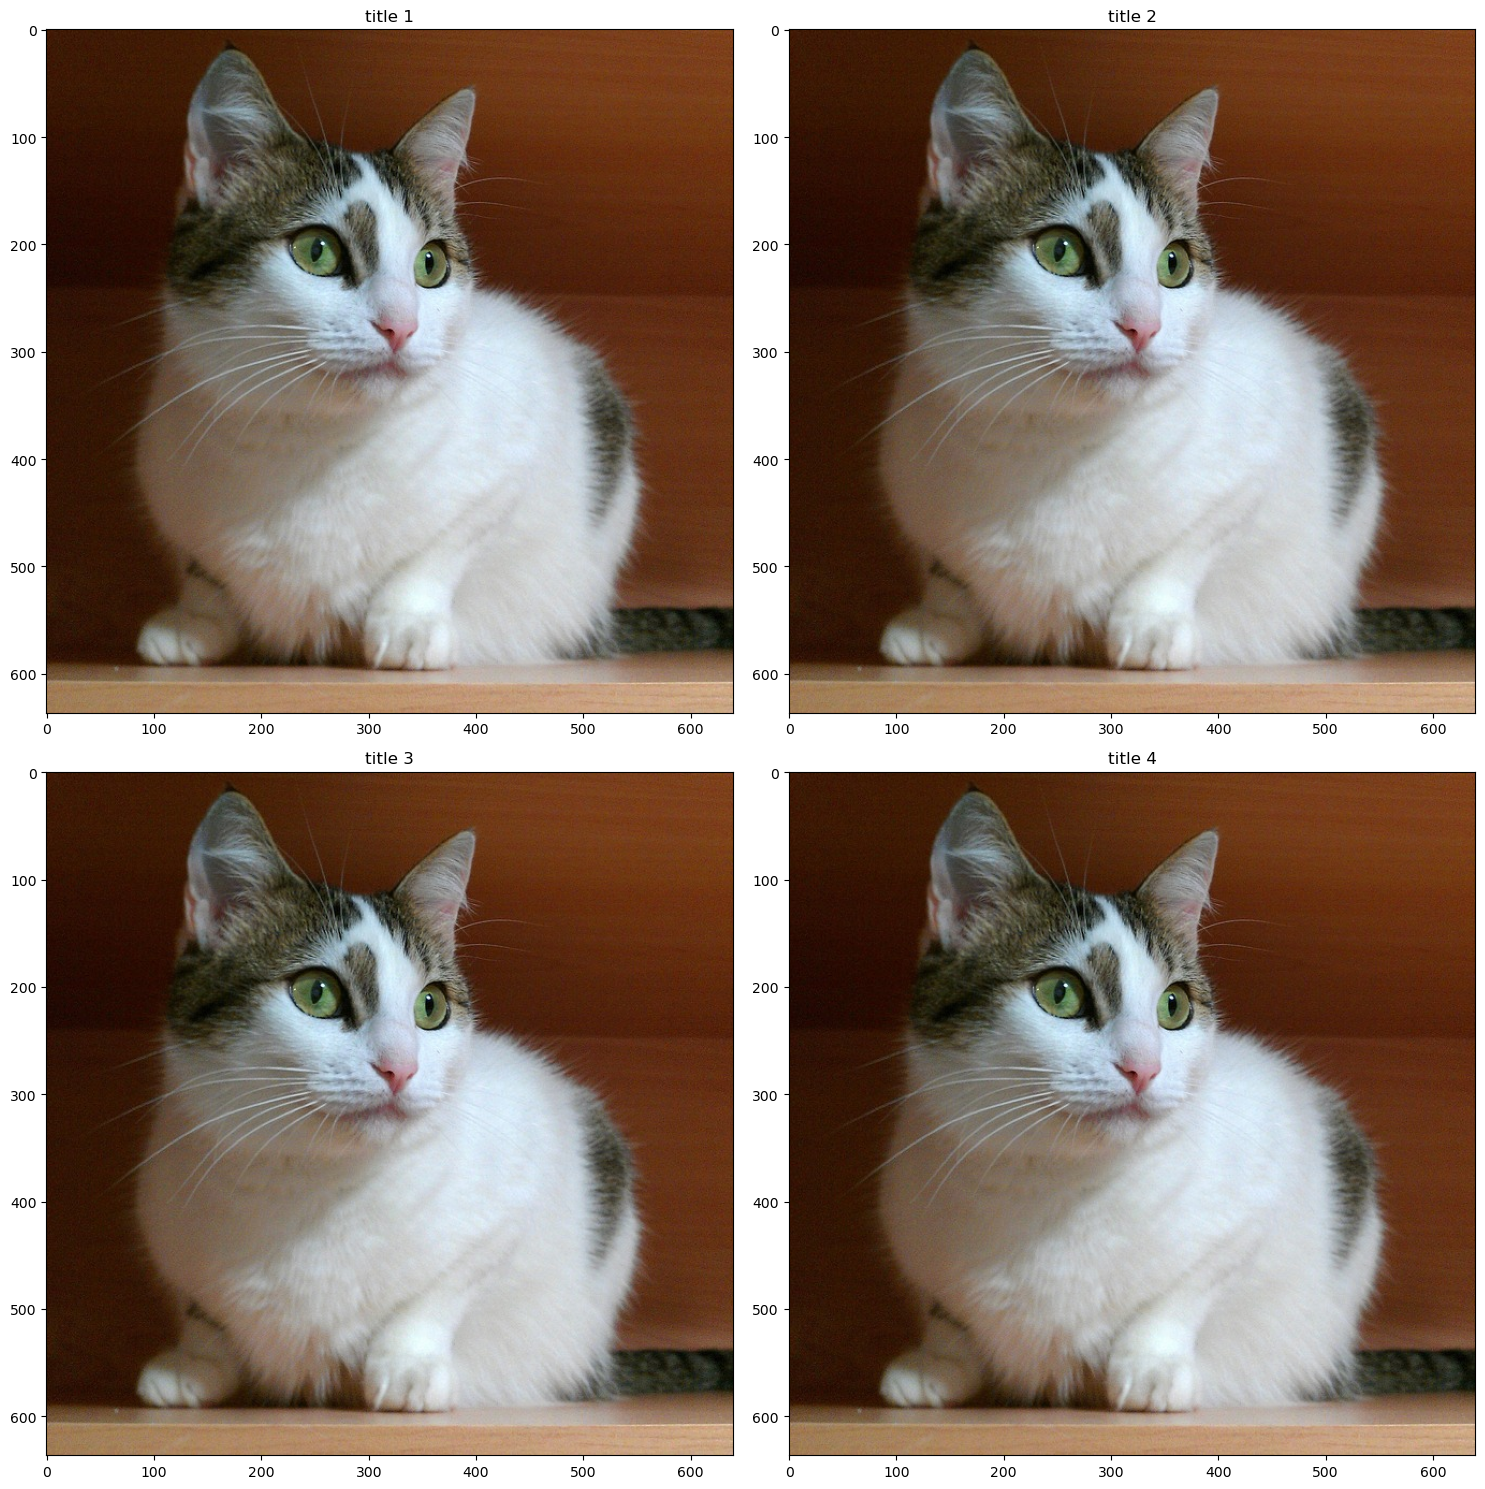

In [61]:
# 使用 matplitlib subplot 功能同時顯示 4 組結果
opencv_tools.show_img_by_matplotlib_2x2(
    "title 1", img, 
    "title 2", img,
    "title 3", img, 
    "title 4", img
)